# Model Evaluation

In [1]:
import json

with open("best_params_multi.json", "r") as f:
    best_params_multi = json.load(f)

print(best_params_multi)

with open("best_params_uni.json", "r") as f:
    best_params_uni = json.load(f)

print(best_params_uni)

{'linear_regression': {}, 'random_forest': {'n_estimators': 300, 'max_depth': None}, 'xgboost': {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.9}, 'lstm': {'lr': 0.001, 'units': 64}}
{'linear_regression': {}, 'random_forest': {'n_estimators': 400, 'max_depth': 10}, 'xgboost': {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8}, 'lstm': {'lr': 0.001, 'units': 64}}


In [10]:
import joblib
best_lr_multi_params = joblib.load("best_lr_multi.pkl")
best_rf_multi_params = joblib.load("best_rf_multi.pkl")
best_xgb_multi_params = joblib.load("best_xgb_multi.pkl")
best_lstm_multi_params = joblib.load("best_lstm_multi.pkl")

best_lr_uni_params = joblib.load("best_lr_uni.pkl")
best_rf_uni_params = joblib.load("best_rf_uni.pkl")
best_xgb_uni_params = joblib.load("best_xgb_uni.pkl")
best_lstm_uni_params = joblib.load("best_lstm_uni.pkl")


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from model_fitting import (
    build_linear_regression,
    build_random_forest,
    build_xgb,
    train_lstm
)




df_train_uni = pd.read_csv("/Users/Owner/cmse492_project/data/processed/Univariate_data/Univariate_train_U.csv")
df_test_uni = pd.read_csv("/Users/Owner/cmse492_project/data/processed/Univariate_data/Univariate_test_U.csv")

df_train_multi = pd.read_csv("/Users/Owner/cmse492_project/data/processed/Multivariate_data/Multivariate_train_M.csv")
df_test_multi = pd.read_csv("/Users/Owner/cmse492_project/data/processed/Multivariate_data/Multivariate_test_M.csv")

target = "SO2"
window = 24


In [21]:
for df in [df_uni_train, df_uni_test, df_multi_train, df_multi_test]:
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df.sort_values("datetime", inplace=True)
        df.reset_index(drop=True, inplace=True)

In [24]:
results = {}

from model_fitting import train_model

def evaluate_sklearn(model, df_train, df_test, name):
    model, X_test, y_test = train_model(model, df_train, df_test, target=target)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(f"{name} Test MSE = {mse:.4f}")
    return mse, preds, y_test

In [25]:
df_train_multi = df_train_multi.drop(columns=["datetime"])
df_test_multi = df_test_multi.drop(columns=["datetime"])

In [26]:
print("\n=== MULTIVARIATE EVALUATION ===")

# Linear Regression
lr_multi = build_linear_regression(**best_lr_multi_params["params"])
results["LR Multi"], lr_multi_preds, lr_multi_y = evaluate_sklearn(
    lr_multi, df_train_multi, df_test_multi, "Linear Regression (Multi)"
)

# Random Forest
rf_multi = build_random_forest(**best_rf_multi_params["params"])
results["RF Multi"], rf_multi_preds, rf_multi_y = evaluate_sklearn(
    rf_multi, df_train_multi, df_test_multi, "Random Forest (Multi)"
)

# XGBoost
xgb_multi = build_xgb(**best_xgb_multi_params["params"])
results["XGB Multi"], xgb_multi_preds, xgb_multi_y = evaluate_sklearn(
    xgb_multi, df_train_multi, df_test_multi, "XGBoost (Multi)"
)



=== MULTIVARIATE EVALUATION ===
Linear Regression (Multi) Test MSE = 0.0355
Random Forest (Multi) Test MSE = 0.0814
XGBoost (Multi) Test MSE = 0.0640


In [30]:
df_train_uni = df_train_uni.drop(columns=["datetime"])
df_test_uni = df_test_uni.drop(columns=["datetime"])

In [31]:
print("\n=== UNIVARIATE EVALUATION ===")

lr_uni = build_linear_regression(**best_lr_uni_params["params"])
results["LR Uni"], lr_uni_preds, lr_uni_y = evaluate_sklearn(
    lr_uni, df_train_uni, df_test_uni, "Linear Regression (Uni)"
)

rf_uni = build_random_forest(**best_rf_uni_params["params"])
results["RF Uni"], rf_uni_preds, rf_uni_y = evaluate_sklearn(
    rf_uni, df_train_uni, df_test_uni, "Random Forest (Uni)"
)

xgb_uni = build_xgb(**best_xgb_uni_params["params"])
results["XGB Uni"], xgb_uni_preds, xgb_uni_y = evaluate_sklearn(
    xgb_uni, df_train_uni, df_test_uni, "XGBoost (Uni)"
)

results


=== UNIVARIATE EVALUATION ===
Linear Regression (Uni) Test MSE = 0.1195
Random Forest (Uni) Test MSE = 0.1677
XGBoost (Uni) Test MSE = 0.2083


{'LR Multi': 0.0355191133254124,
 'RF Multi': 0.081377637600457,
 'XGB Multi': 0.06398701263931329,
 'LR Uni': 0.11949492361392966,
 'RF Uni': 0.167736920436248,
 'XGB Uni': 0.20833150632253994}

In [32]:
def evaluate_lstm_wrapper(df_train, df_test, params, name):
    model, history, X_test, y_test = train_lstm(
        df_train,
        df_test,
        target=target,
        window=window,
        epochs=5,
        batch_size=32,
        lr=params["params"]["lr"],
        units=params["params"]["units"]
    )
    
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(f"{name} Test MSE = {mse:.4f}")
    return mse, preds, y_test, history

In [34]:
df_train_multi = df_train_multi.drop(columns=["datetime"], errors="ignore")
df_test_multi = df_test_multi.drop(columns=["datetime"], errors="ignore")

df_train_multi = df_train_multi.apply(pd.to_numeric, errors="coerce")
df_test_multi = df_test_multi.apply(pd.to_numeric, errors="coerce")

df_train_multi = df_train_multi.dropna()
df_test_multi = df_test_multi.dropna()

In [35]:
results["LSTM Multi"], lstm_multi_preds, lstm_multi_y, lstm_multi_hist = \
    evaluate_lstm_wrapper(df_train_multi, df_test_multi, best_lstm_multi_params, "LSTM (Multi)")


Epoch 1/5


C:\Users\Owner\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.8581 - val_loss: 1.4736
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.6966 - val_loss: 1.3000
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.6219 - val_loss: 1.1963
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.5622 - val_loss: 0.8515
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5214 - val_loss: 0.6544
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step  
LSTM (Multi) Test MSE = 0.6544


In [37]:
df_train_uni = df_train_uni.drop(columns=["datetime"], errors="ignore")
df_test_uni = df_test_uni.drop(columns=["datetime"], errors="ignore")

df_train_uni = df_train_uni.apply(pd.to_numeric, errors="coerce")
df_test_uni = df_test_uni.apply(pd.to_numeric, errors="coerce")

df_train_uni = df_train_uni.dropna()
df_test_uni = df_test_uni.dropna()

In [38]:
results["LSTM Uni"], lstm_uni_preds, lstm_uni_y, lstm_uni_hist = \
    evaluate_lstm_wrapper(df_train_uni, df_test_uni, best_lstm_uni_params, "LSTM (Uni)")

Epoch 1/5


C:\Users\Owner\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.8723 - val_loss: 1.3945
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7007 - val_loss: 1.1906
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.6181 - val_loss: 1.1168
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5653 - val_loss: 0.8304
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5122 - val_loss: 1.0568
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step  
LSTM (Uni) Test MSE = 1.0568


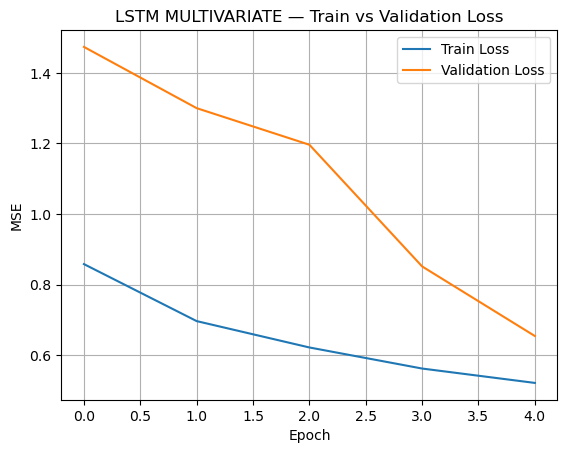

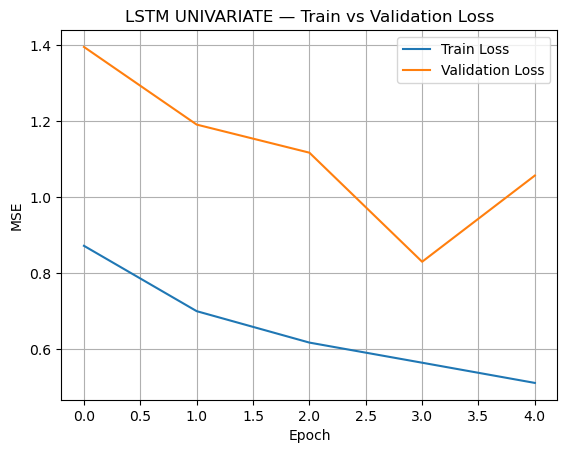

In [39]:
def plot_lstm_history(history, title):
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_lstm_history(lstm_multi_hist, "LSTM MULTIVARIATE — Train vs Validation Loss")
plot_lstm_history(lstm_uni_hist,  "LSTM UNIVARIATE — Train vs Validation Loss")

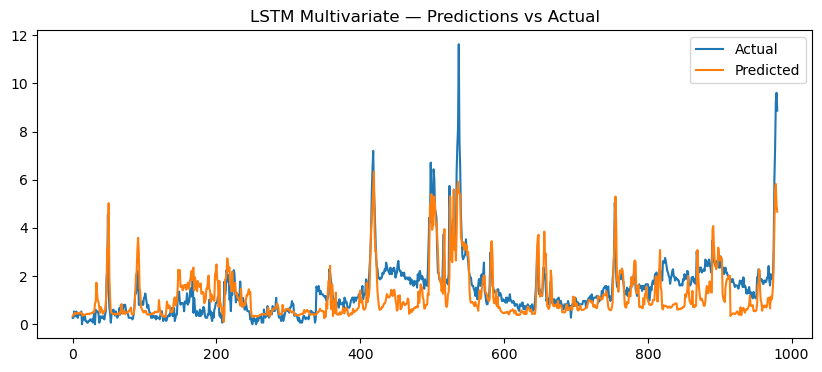

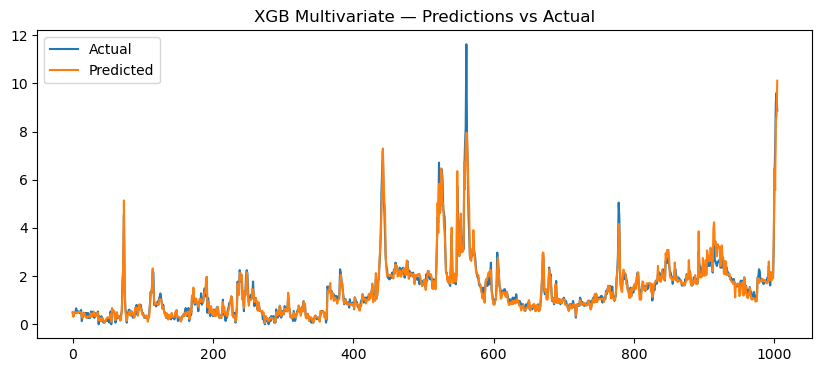

In [40]:
def plot_preds(y_true, y_pred, title):
    plt.figure(figsize=(10,4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

plot_preds(lstm_multi_y, lstm_multi_preds, "LSTM Multivariate — Predictions vs Actual")
plot_preds(xgb_multi_y, xgb_multi_preds, "XGB Multivariate — Predictions vs Actual")

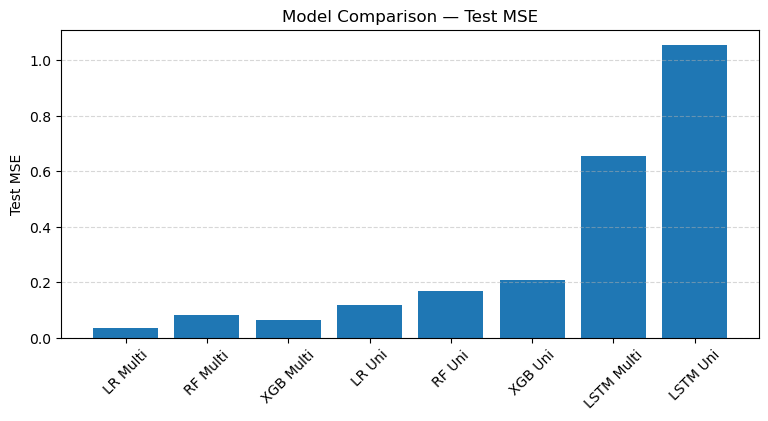

In [41]:
plt.figure(figsize=(9,4))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Test MSE")
plt.title("Model Comparison — Test MSE")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()